# Mall-Costumer

## Import Libraries

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

## Data Cleaning

In [29]:
df=pd.read_csv("Mall_Customers.csv")
df.info()
df.describe()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


np.int64(0)

## Without Scaling

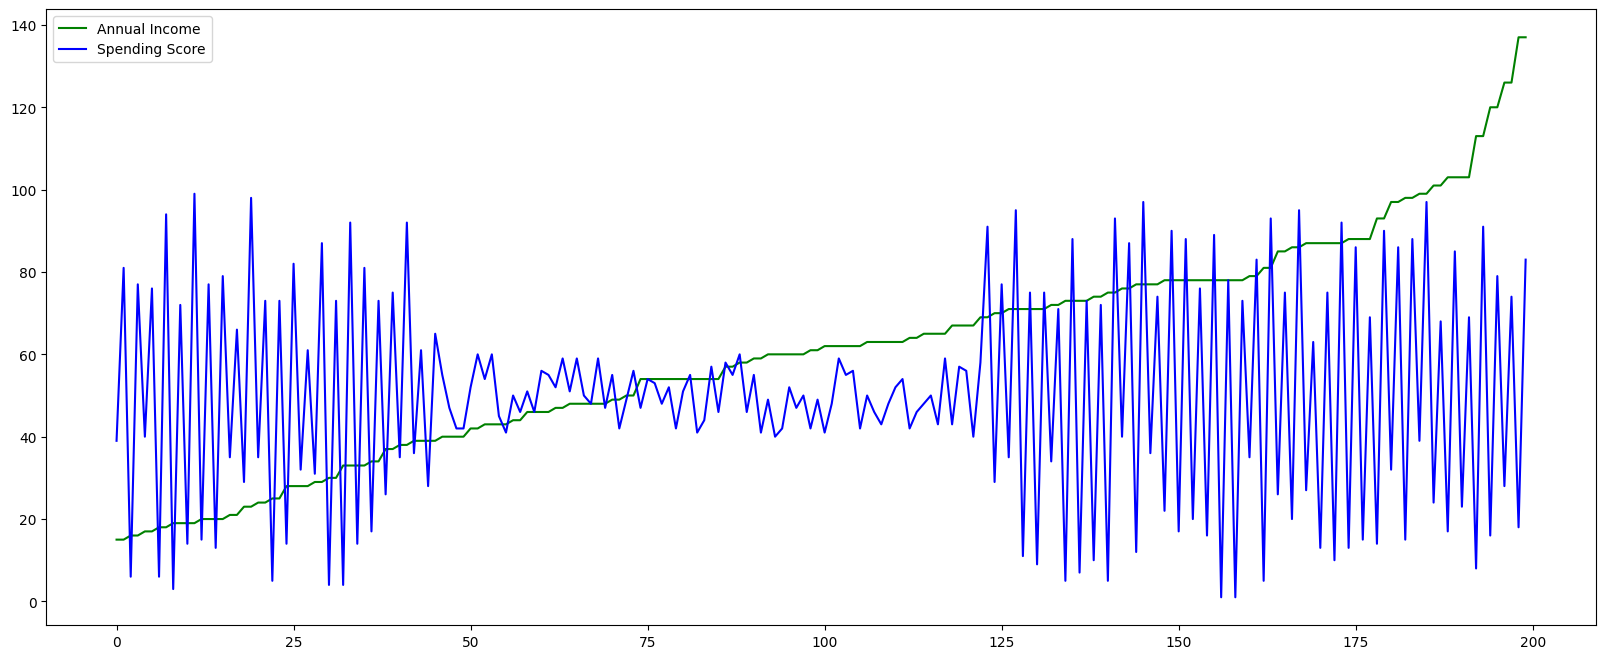

In [30]:
plt.figure(figsize=(20,8))
# plt.subplot(1,2,1)
plt.plot(df["Annual Income (k$)"],"g", label="Annual Income")

# plt.subplot(1,2,2)
plt.plot(df["Spending Score (1-100)"],"b", label="Spending Score")
plt.legend()

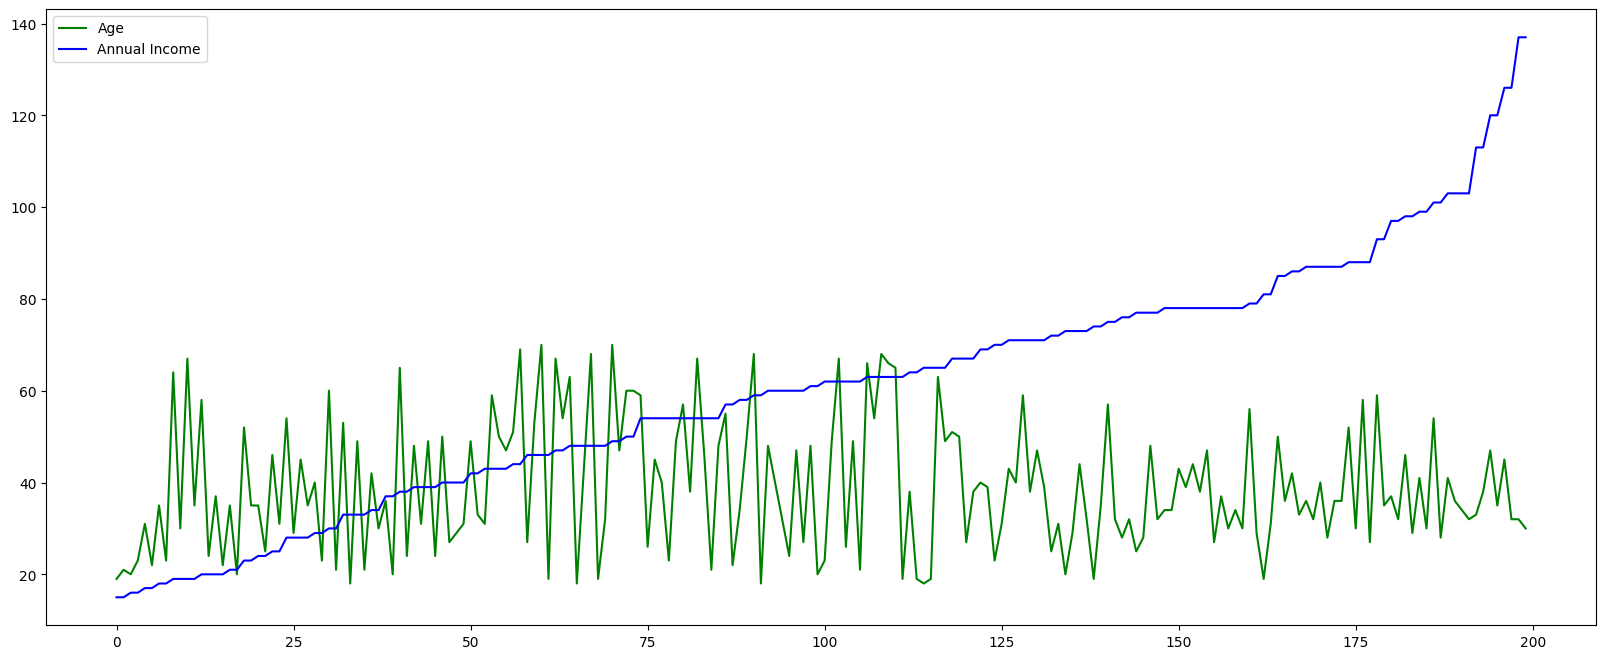

In [31]:
plt.figure(figsize=(20,8))
plt.plot(df["Age"], "g", label="Age")
plt.plot(df["Annual Income (k$)"], "b", label="Annual Income")
plt.legend()

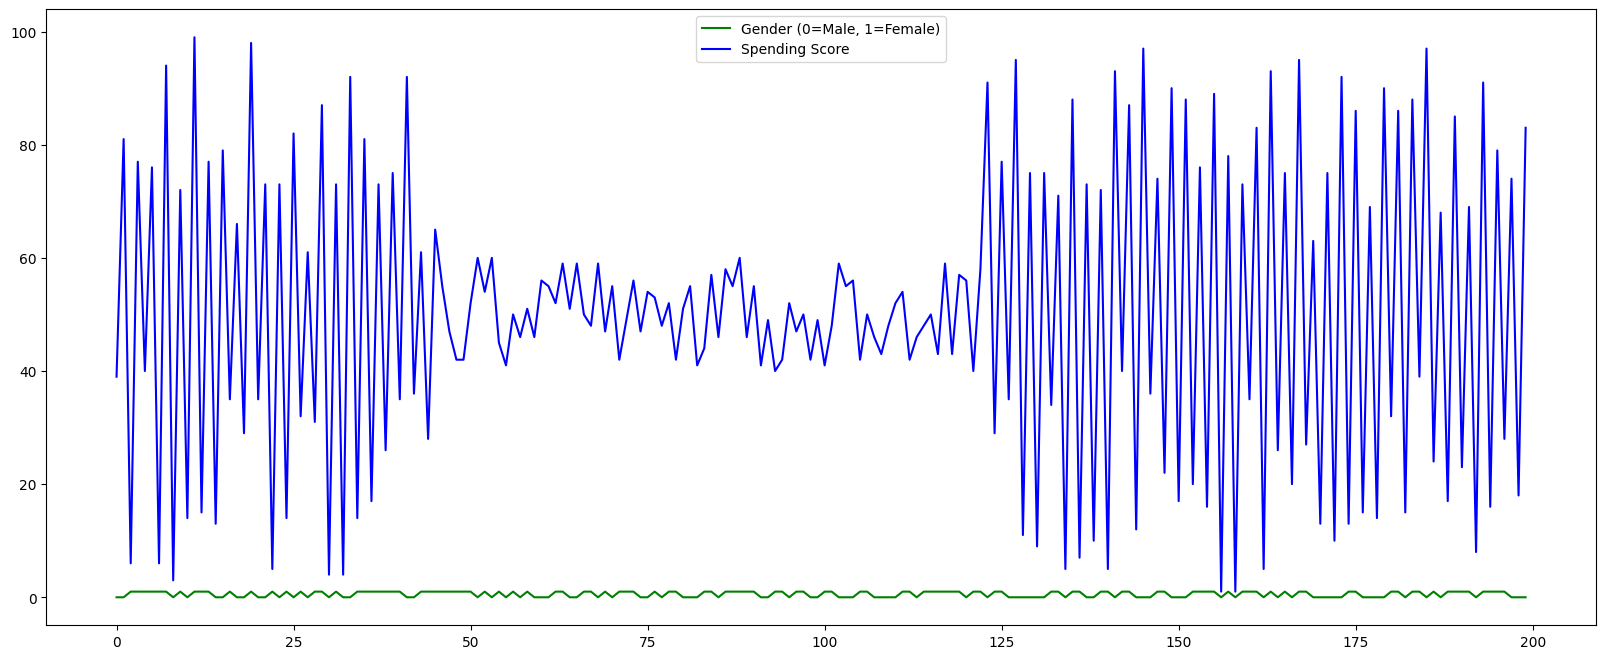

In [32]:
gender_encoded = df["Gender"].map({"Male": 0, "Female": 1})

plt.figure(figsize=(20,8))
plt.plot(gender_encoded, "g", label="Gender (0=Male, 1=Female)")
plt.plot(df["Spending Score (1-100)"], "b", label="Spending Score")
plt.legend()

## Standard Scaling

In [33]:
Annual_Income= (df["Annual Income (k$)"] - df["Annual Income (k$)"].mean()) / df["Annual Income (k$)"].std()
Annual_Income.mean(), Annual_Income.std()

(np.float64(-2.1316282072803005e-16), np.float64(1.0))

In [34]:
Spending_Score= (df["Spending Score (1-100)"] - df["Spending Score (1-100)"].mean()) / df["Spending Score (1-100)"].std()
Spending_Score.mean(), Spending_Score.std()

(np.float64(-1.376676550535194e-16), np.float64(1.0))

In [35]:
Age= (df["Age"] - df["Age"].mean()) / df["Age"].std()
Age.mean(), Age.std()

(np.float64(-1.021405182655144e-16), np.float64(1.0))

In [36]:
Gender= (gender_encoded - gender_encoded.mean()) / gender_encoded.std()
Gender.mean(), Gender.std()

(np.float64(-7.549516567451065e-17), np.float64(1.0))

In [37]:
scaler = StandardScaler()

Annual_Income_scaled = scaler.fit_transform(df[["Annual Income (k$)"]])
Spending_Score_scaled = scaler.fit_transform(df[["Spending Score (1-100)"]])
Age_scaled = scaler.fit_transform(df[["Age"]])
Gender_scaled = scaler.fit_transform(gender_encoded.values.reshape(-1,1)
)

In [38]:
print(df["Annual Income (k$)"].mean())
print(df["Annual Income (k$)"].std())

print(Annual_Income_scaled.mean())
print(Annual_Income_scaled.std())

60.56
26.264721165271244
-2.1316282072803005e-16
0.9999999999999999


## Plots

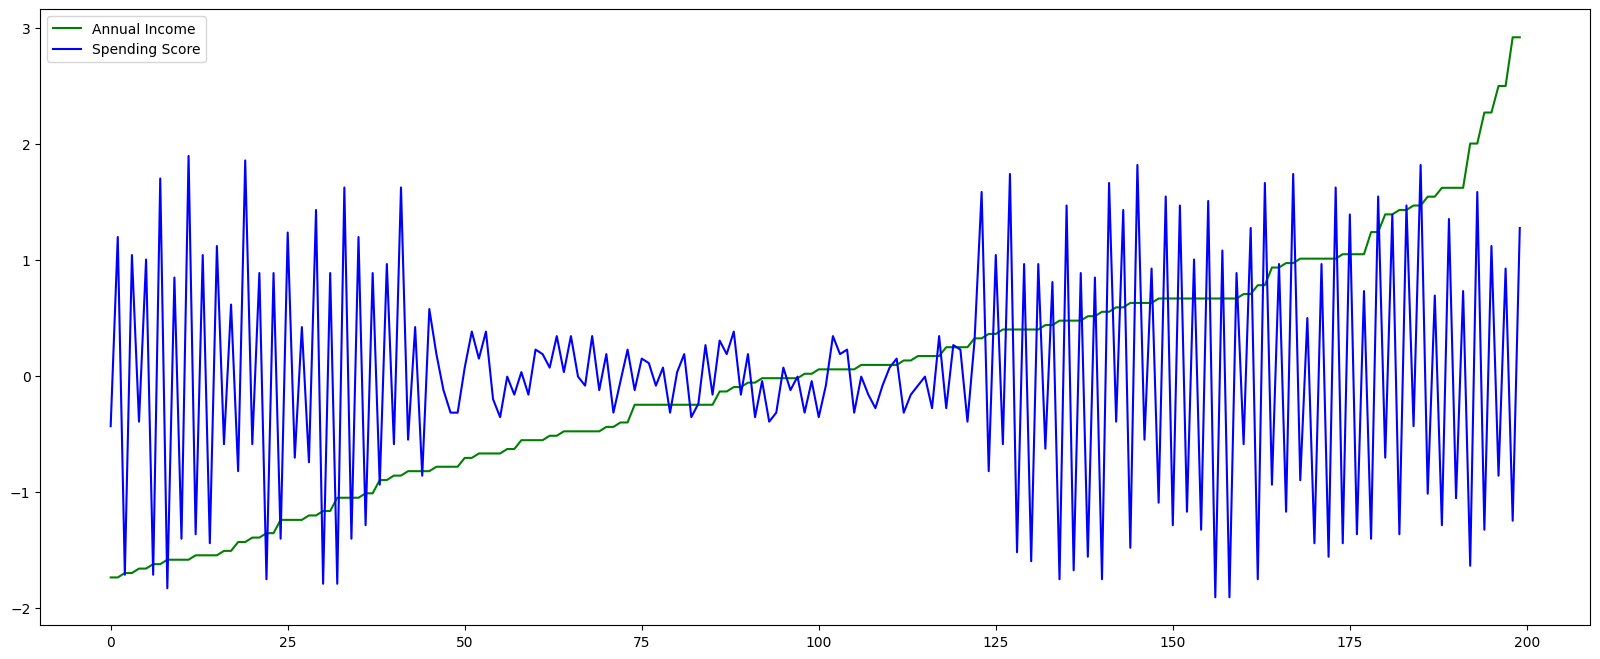

In [39]:
plt.figure(figsize=(20,8))
plt.plot(Annual_Income_scaled,"g", label="Annual Income")

plt.plot(Spending_Score_scaled,"b", label="Spending Score")
plt.legend()

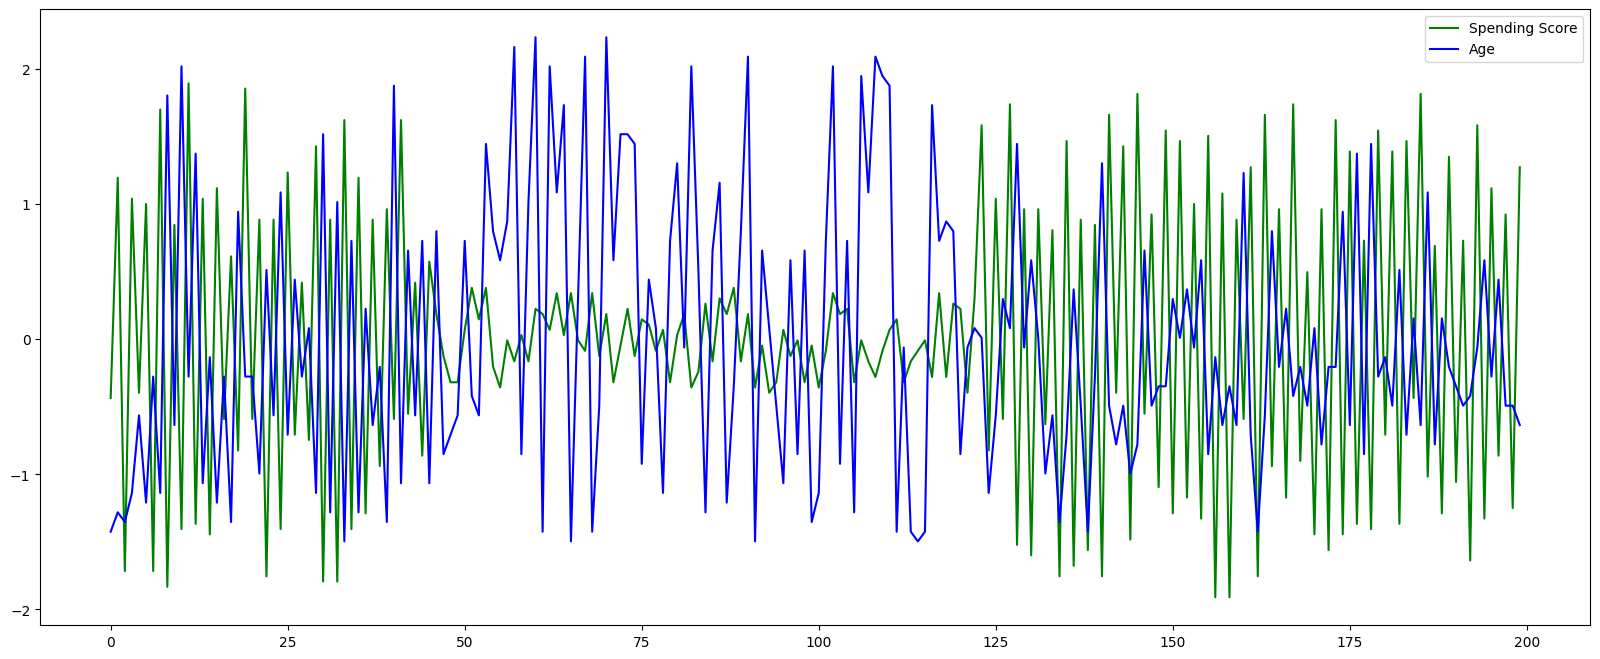

In [40]:
plt.figure(figsize=(20,8))
plt.plot(Spending_Score_scaled,"g", label="Spending Score")

plt.plot(Age_scaled,"b", label="Age")
plt.legend()

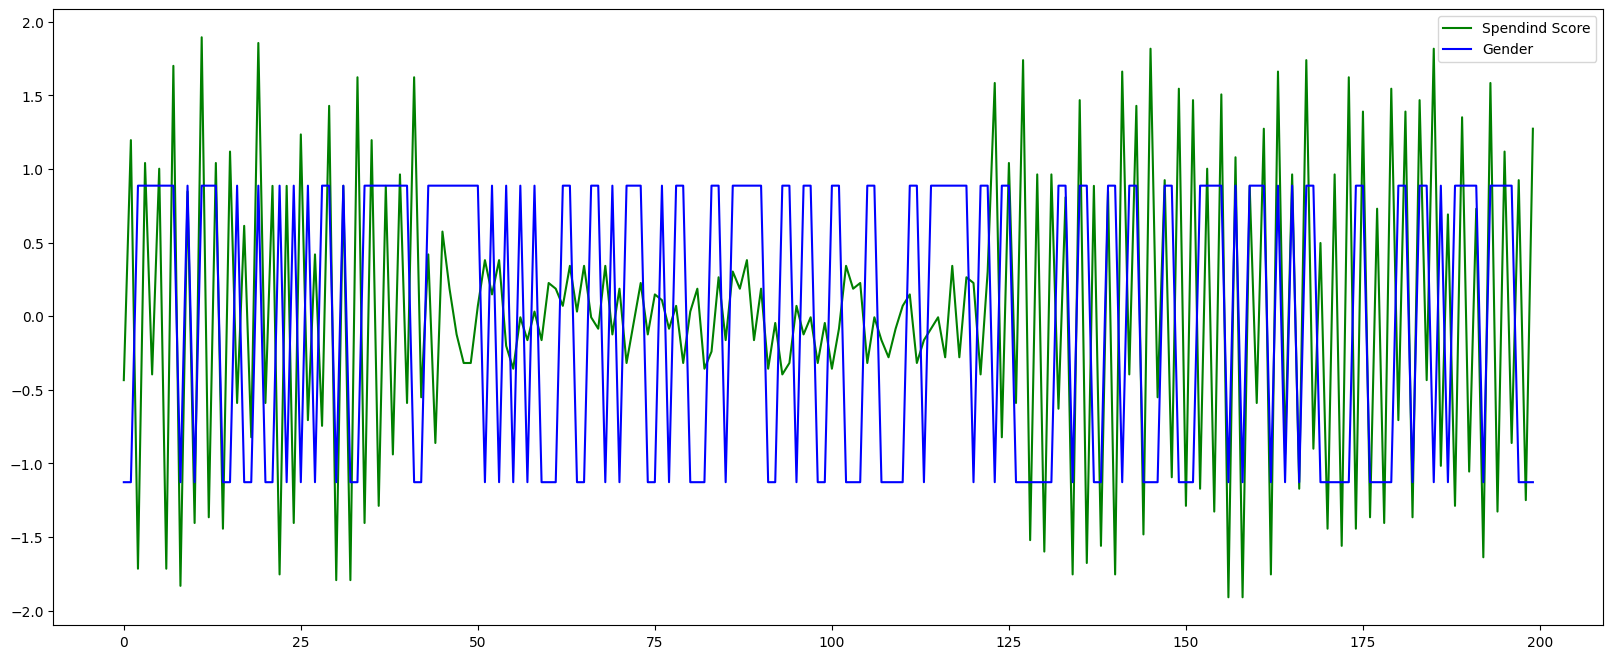

In [41]:
plt.figure(figsize=(20,8))
plt.plot(Spending_Score_scaled,"g", label="Spendind Score")

plt.plot(Gender_scaled,"b", label="Gender")
plt.legend()

## Pearson

In [42]:
from scipy.stats import pearsonr

pearsonr(df["Age"],df["Annual Income (k$)"])
pearsonr(df["Spending Score (1-100)"],df["Annual Income (k$)"])

PearsonRResult(statistic=np.float64(0.009902848094037619), pvalue=np.float64(0.8893134370273993))

## Corrolation

<Axes: >

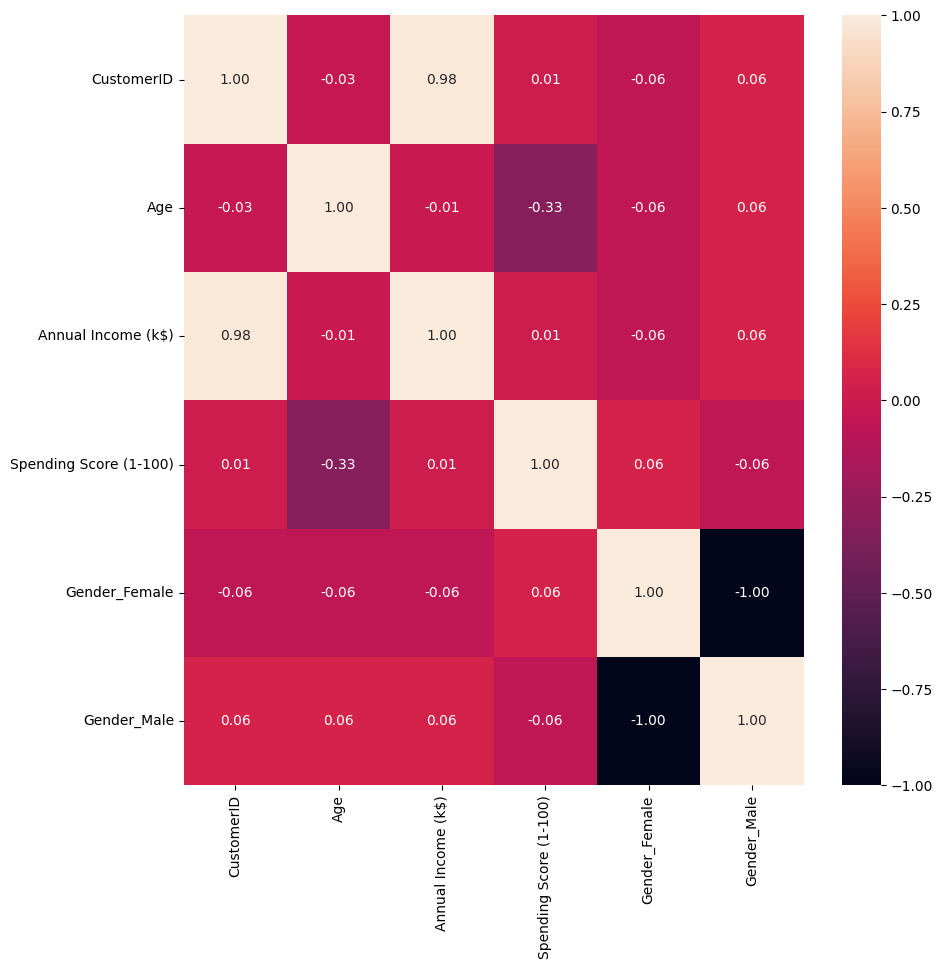

In [43]:
df_encoded = pd.get_dummies(df, columns=["Gender"])
corr = df_encoded.corr()
plt.figure(figsize=(10,10))
sns.heatmap(df_encoded.corr(), annot=True, fmt="0.2f")